<a href="https://colab.research.google.com/github/janosv246/MPA-MLF/blob/main/Lab_08/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential, load_model
from keras.optimizers import Adam

### 1.1 Generating dataset

In [162]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [163]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [164]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [165]:
no_training_epochs = 5

### 1.3 Data examination

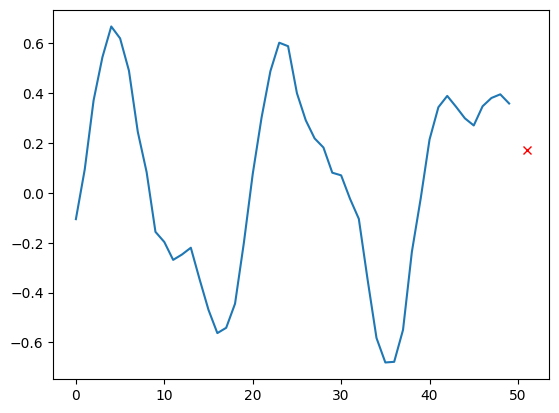

In [166]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [167]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [168]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [169]:
model_linear.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [170]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2801 - mean_squared_error: 0.2801 - val_loss: 0.1141 - val_mean_squared_error: 0.1141
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0747 - mean_squared_error: 0.0747 - val_loss: 0.0524 - val_mean_squared_error: 0.0524
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0389 - mean_squared_error: 0.0389 - val_loss: 0.0296 - val_mean_squared_error: 0.0296
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0196 - val_mean_squared_error: 0.0196
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0144 - val_mean_squared_error: 0.0144


In [171]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

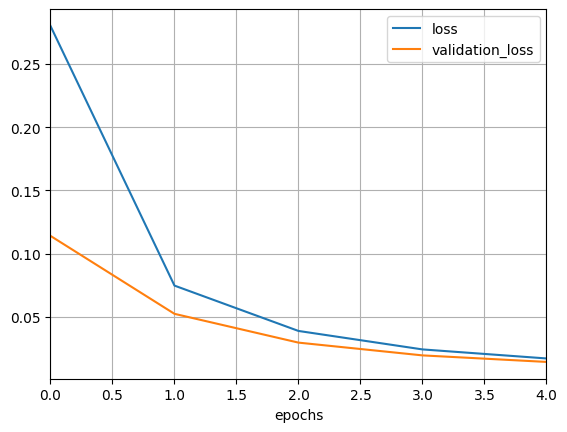

In [172]:
plot_function(history_linear)

In [173]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.014234035275876522
Test MSE:  0.014234035275876522


### 1.5 Simple RNN Model

In [174]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [175]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [176]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1373 - mean_squared_error: 0.1373 - val_loss: 0.1221 - val_mean_squared_error: 0.1221
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1081 - mean_squared_error: 0.1081 - val_loss: 0.0932 - val_mean_squared_error: 0.0932
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0819 - mean_squared_error: 0.0819 - val_loss: 0.0693 - val_mean_squared_error: 0.0693
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0596 - mean_squared_error: 0.0596 - val_loss: 0.0485 - val_mean_squared_error: 0.0485
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0408 - mean_squared_error: 0.0408 - val_loss: 0.0320 - val_mean_squared_error: 0.0320


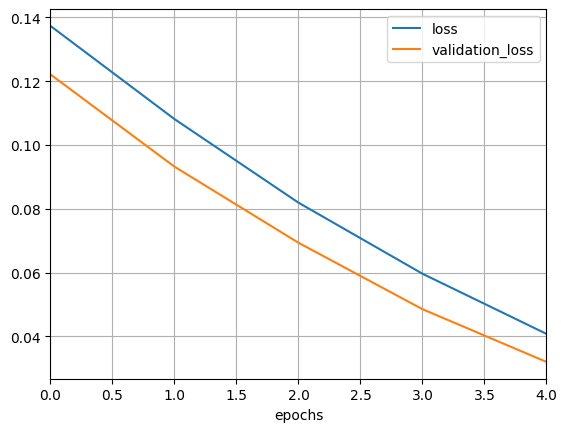

In [177]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [178]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [179]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [180]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0042 - val_mean_squared_error: 0.0042
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0031 - val_mean_squared_error: 0.0031
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0031 - val_mean_squared_error: 0.0031
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0029 - val_mean_squared_error: 0.0029


In [181]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0031737256795167923
Test MSE:  0.0031737256795167923


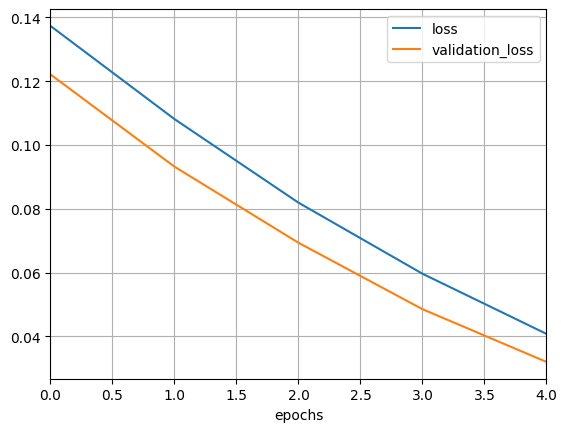

In [182]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [183]:
from tensorflow.keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [184]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

### 2.2 - Dataset examination

TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [185]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [186]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [187]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [188]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [189]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [190]:
optimizer = Adam(learning_rate = 0.001)

In [191]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [192]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4988 - loss: 0.7002 - val_accuracy: 0.4938 - val_loss: 0.6982
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5005 - loss: 0.6967 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5049 - loss: 0.6949 - val_accuracy: 0.5062 - val_loss: 0.6948
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5053 - loss: 0.6960 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5068 - loss: 0.6950 - val_accuracy: 0.4938 - val_loss: 0.7006


In [193]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6992378234863281
Test accuracy:  50.0 %


LSTM Model

In [194]:
model_lstm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

In [195]:
optimizer_lstm = Adam(learning_rate = 0.001)
model_lstm.compile(loss="binary_crossentropy", optimizer=optimizer_lstm, metrics=["accuracy"])

In [196]:
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5668 - loss: 0.6797 - val_accuracy: 0.6182 - val_loss: 0.6681
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7122 - loss: 0.5525 - val_accuracy: 0.7928 - val_loss: 0.4623
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8083 - loss: 0.4204 - val_accuracy: 0.8232 - val_loss: 0.3984
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8382 - loss: 0.3696 - val_accuracy: 0.8340 - val_loss: 0.3759
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8488 - loss: 0.3421 - val_accuracy: 0.8352 - val_loss: 0.3669


In [197]:
score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print('LSTM Test loss:', score_lstm[0])
print(f'LSTM Test accuracy: ', score_lstm[1]*100, "% ")

LSTM Test loss: 0.36009758710861206
LSTM Test accuracy:  83.57999920845032 % 


GRU Model

In [198]:
model_gru = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

In [199]:
optimizer_gru = Adam(learning_rate = 0.001)
model_gru.compile(loss="binary_crossentropy", optimizer=optimizer_gru, metrics=["accuracy"])

In [200]:
history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5166 - loss: 0.6933 - val_accuracy: 0.5606 - val_loss: 0.6805
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7717 - loss: 0.4696 - val_accuracy: 0.8100 - val_loss: 0.4212
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8458 - loss: 0.3531 - val_accuracy: 0.8382 - val_loss: 0.3846
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8577 - loss: 0.3248 - val_accuracy: 0.8128 - val_loss: 0.4177
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8694 - loss: 0.3048 - val_accuracy: 0.8256 - val_loss: 0.3927


In [201]:
score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print('GRU Test loss:', score_gru[0])
print(f'GRU Test accuracy: ', score_gru[1]*100, "% ")

GRU Test loss: 0.3780619502067566
GRU Test accuracy:  83.0560028553009 % 


Comparison of Models

SimpleRNN Test Accuracy: 50.00%
LSTM Test Accuracy: 83.58%
GRU Test Accuracy: 83.06%


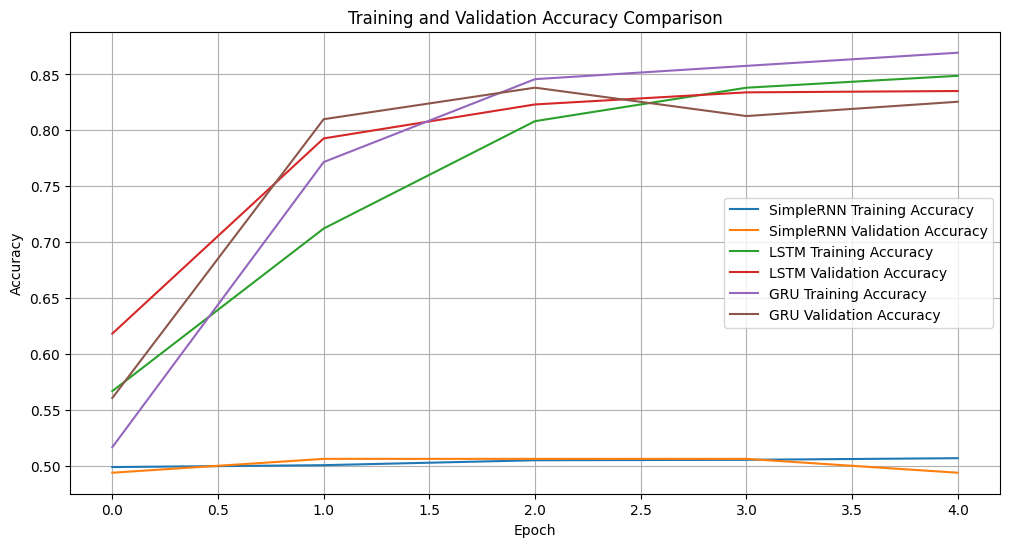

In [202]:
print(f"SimpleRNN Test Accuracy: {score[1]*100:.2f}%")
print(f"LSTM Test Accuracy: {score_lstm[1]*100:.2f}%")
print(f"GRU Test Accuracy: {score_gru[1]*100:.2f}%")


plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='SimpleRNN Training Accuracy')
plt.plot(history.history['val_accuracy'], label='SimpleRNN Validation Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.plot(history_gru.history['accuracy'], label='GRU Training Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation Accuracy')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Test

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, None, 128)      │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,057 (1.18 MB)

 Trainable params: 309,057 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5946 - loss: 0.6691 - val_accuracy: 0.6004 - val_loss: 0.6702
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5553 - loss: 0.6826 - val_accuracy: 0.5066 - val_loss: 0.6944
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5183 - loss: 0.6926 - val_accuracy: 0.5098 - val_loss: 0.6877
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6714 - loss: 0.6146 - val_accuracy: 0.7182 - val_loss: 0.5548
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7547 - loss: 0.5353 - val_accuracy: 0.7758 - val_loss: 0.4955
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7837 - loss: 0.4796 - val_accuracy: 0.7918 - val_loss: 0.4684
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8020 - loss: 0.4406 - val_accuracy: 0.8100 - val_loss: 0.4279
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8170 - loss: 0.4139 - va

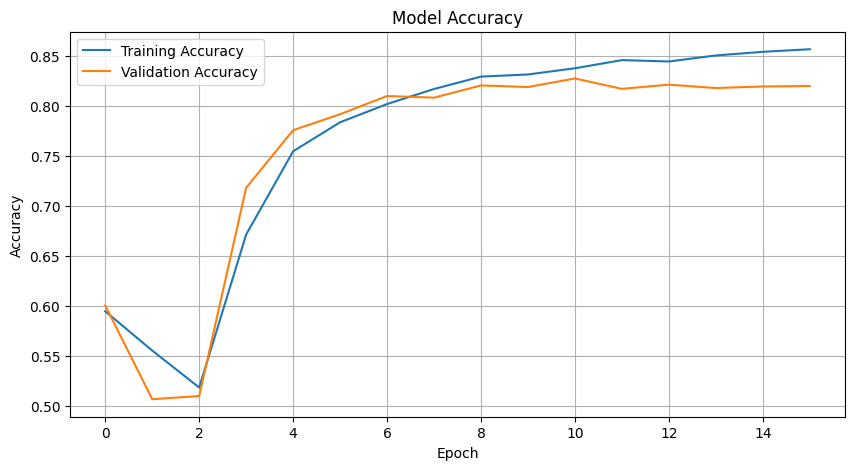

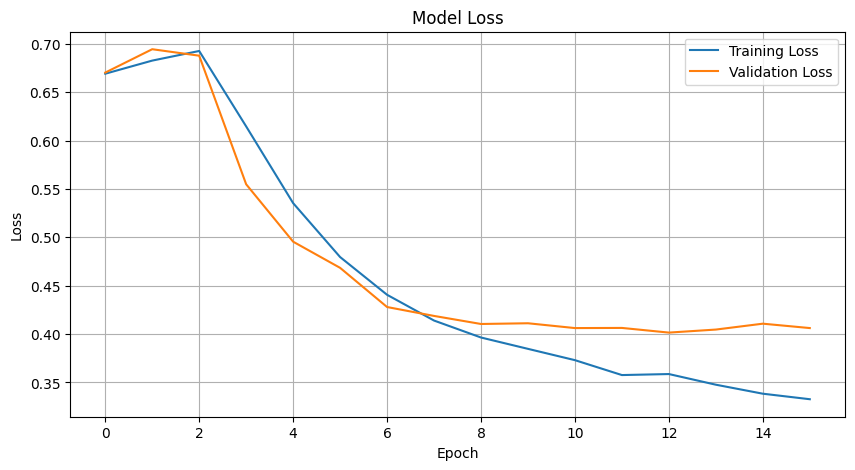

In [223]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

embed_size = 128
vocabulary_size = 1000

model_test = keras.models.Sequential([
    keras.Input(shape=(None,)),
    keras.layers.Embedding(vocabulary_size, embed_size, embeddings_regularizer=keras.regularizers.l2(1e-6)),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(64),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer_test = Adam(learning_rate=0.001)

model_test.compile(loss="binary_crossentropy", optimizer=optimizer_test, metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_test.summary()

history_test = model_test.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stopping],
    batch_size=32
)


score_test = model_test.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_test[0])
print(f'Test accuracy: {score_test[1]*100:.2f} %')

plt.figure(figsize=(10, 5))
plt.plot(history_test.history['accuracy'], label='Training Accuracy')
plt.plot(history_test.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_test.history['loss'], label='Training Loss')
plt.plot(history_test.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()